In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

netflix = pd.read_csv("netflix_cleaned.csv")



# Step 1: Analyze rating categories

In [24]:
# Analyze = examine data closely to understand patterns
rating_counts = netflix['rating'].value_counts()  
print(rating_counts)

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


 # Step 2: Identify the most common genres

In [25]:
# Split multiple genres and explode into separate rows
df_genre = netflix.assign(listed_in=netflix['listed_in'].str.split(', ')).explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

# plotly.express only understand the dataframe that why we change the data into dataframe

In [26]:
df_genre['listed_in']

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
2                 Crime TV Shows
                  ...           
8792    Children & Family Movies
8792                    Comedies
8793                      Dramas
8793        International Movies
8793            Music & Musicals
Name: listed_in, Length: 19300, dtype: object

In [27]:
genre_counts = df_genre['listed_in'].value_counts()
print(genre_counts.head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


# Step 3: Compare ratings across content types

In [28]:
rating_type = netflix.groupby(['type', 'rating']).size().reset_index(name='count') # Group by Type and Rating.
rating_type     


,type,rating,count
0,Movie,G,41
1,Movie,NC-17,3
2,Movie,NR,75
3,Movie,PG,287
4,Movie,PG-13,490
5,Movie,R,797
6,Movie,TV-14,1427
7,Movie,TV-G,126
8,Movie,TV-MA,2064
9,Movie,TV-PG,540


In [29]:
# Pivot to compare side by side
rating_pivot = rating_type.pivot(index='rating', columns='type', values='count').fillna(0)
print(rating_pivot)

type       Movie  TV Show
rating                   
G           41.0      0.0
NC-17        3.0      0.0
NR          75.0      4.0
PG         287.0      0.0
PG-13      490.0      0.0
R          797.0      2.0
TV-14     1427.0    730.0
TV-G       126.0     94.0
TV-MA     2064.0   1145.0
TV-PG      540.0    321.0
TV-Y       131.0    175.0
TV-Y7      139.0    194.0
TV-Y7-FV     5.0      1.0
UR           3.0      0.0


# Step 4: Create interactive visualizations

In [31]:
# "Interactive" usually means charts you can hover, zoom, or click on — for that, we use Plotly instead of static matplotlib/seaborn charts.

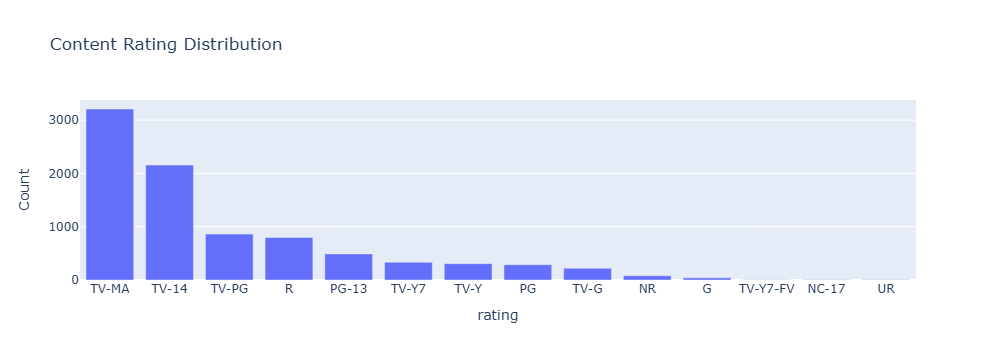

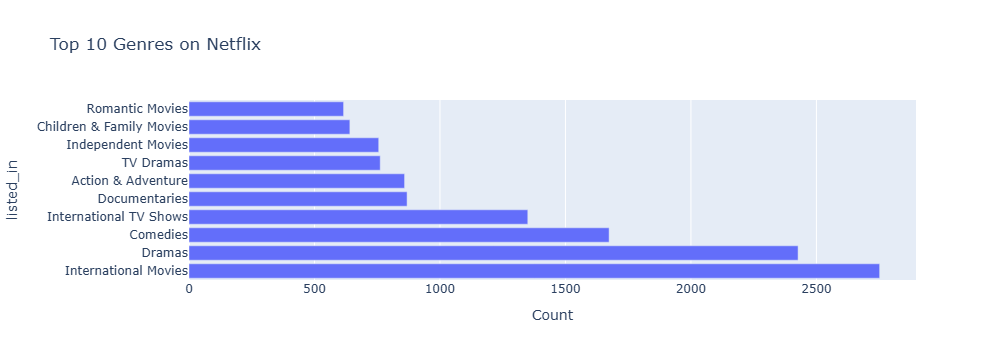

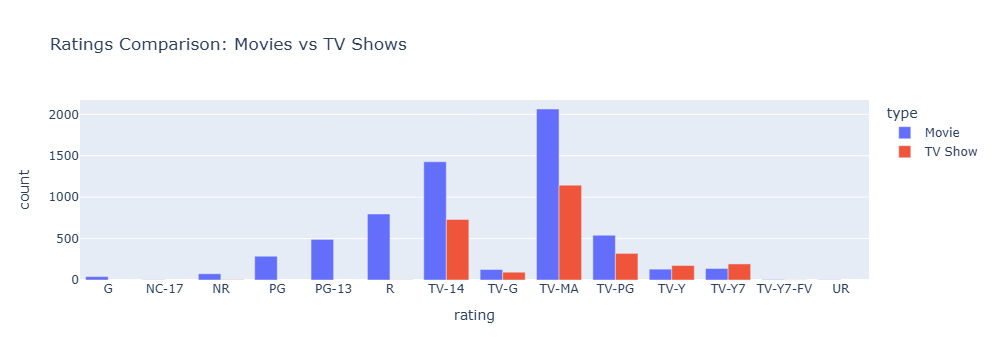

In [30]:
import plotly.express as px

# Interactive bar chart - Rating distribution
fig1 = px.bar(rating_counts, x=rating_counts.index, y=rating_counts.values, 
              labels={'x': 'Rating', 'y': 'Count'},
              title="Content Rating Distribution")
fig1.show()

# Interactive bar chart - Top 10 genres
top_genres = genre_counts.head(10)
fig2 = px.bar(top_genres, x=top_genres.values, y=top_genres.index, orientation='h',
              labels={'x': 'Count', 'y': 'Genre'},
              title="Top 10 Genres on Netflix")
fig2.show()

# Interactive comparison - Rating by content type
fig3 = px.bar(rating_type, x='rating', y='count', color='type', barmode='group',
              title="Ratings Comparison: Movies vs TV Shows")
fig3.show()

In [32]:
most_common_rating = rating_counts.idxmax()
most_common_genre = genre_counts.idxmax()

print(f"The most common content rating is '{most_common_rating}', suggesting Netflix targets a specific age group heavily.")
print(f"The most popular genre is '{most_common_genre}'.")

mature_ratings = ['TV-MA', 'R', 'NC-17']
mature_pct = (netflix['rating'].isin(mature_ratings).sum() / len(netflix)) * 100
print(f"{mature_pct:.1f}% of content is rated for mature audiences.")

The most common content rating is 'TV-MA', suggesting Netflix targets a specific age group heavily.
The most popular genre is 'International Movies'.
45.6% of content is rated for mature audiences.


 # Step 5: Audience Insights

1) TV-MA is the most common rating, indicating Netflix primarily targets mature audiences.
2) TV-14 is also highly represented, suggesting a strong focus on teenage and family audiences.
3) International Movies and Dramas are the most popular genres, showing Netflix's investment in globally diverse content.
4) Movies generally outnumber TV Shows across most rating categories.
5) Genres like Documentaries, Comedies, and Action & Adventure attract a broad audience, helping Netflix serve different viewer   preferences.
6) These insights can help Netflix:
    1)  Recommend content based on audience age groups.
    2)  Plan investments in high-performing genres.
    3)  Balance content production between Movies and TV Shows.